In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix as confusion_matrix_sklearn

def plot_matrix(cm,  labels_name, title=None, thresh=0.8, axis_labels=None,tick_fontsize=16, text_fontsize=14):
    # 利用sklearn中的函数生成混淆矩阵并归一化
    #     cm = metrics.confusion_matrix(y_true, y_pred, labels=labels_name, sample_weight=None)  # 生成混淆矩阵
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # 归一化

    # 画图，如果希望改变颜色风格，可以改变此部分的cmap=pl.get_cmap('Blues')处
    plt.figure(figsize=(6,6), dpi=500)
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    # plt.colorbar()  # 绘制图例
    plt.colorbar().remove()
    # 图像标题
    if title is not None:
        plt.title(title)
    # 绘制坐标
    num_local = np.array(range(len(labels_name)))
    if axis_labels is None:
        axis_labels = labels_name
    plt.xticks(num_local, axis_labels, rotation=45, fontsize=tick_fontsize)
    plt.yticks(num_local, axis_labels, fontsize=tick_fontsize)
    plt.ylabel('True label', fontsize=tick_fontsize)
    plt.xlabel('Predicted label', fontsize=tick_fontsize)

    # 将百分比打印在相应的格子内，大于thresh的用白字，小于的用黑字
    for i in range(np.shape(cm)[0]):
        for j in range(np.shape(cm)[1]):
            # if int(cm[i][j] * 100 + 0.5) > 0:
            plt.text(j, i, format(cm[i][j], '.2f'),
                    fontsize=text_fontsize,
                    ha="center",
                    va="center",
                    color="white" if cm[i][j] > thresh else "black")  # 如果要更改颜色风格，需要同时更改此行

    plt.show()

In [6]:
cm = np.load('cm/use_t4/DASSL-FCcm_7_0.8379769076305221.npy')
# plot_matrix(cm, labels_name=['N', 'FWC', 'FWE', 'RL', 'RO', 'EO', 'CF', 'NC'])
print(cm)

[[1089    0    2    0    0    0    0    0]
 [   0 1040    5   29   20    0    0    0]
 [   0    0  873   15   23  181    0    0]
 [   0    0   10  671   28   29    1  173]
 [   0    0   17    2  890    1    1    0]
 [   0    1  295   10   34  531    9   32]
 [   0    0   31    0   30  311  719    0]
 [   0    0    0    0    1    0    0  864]]


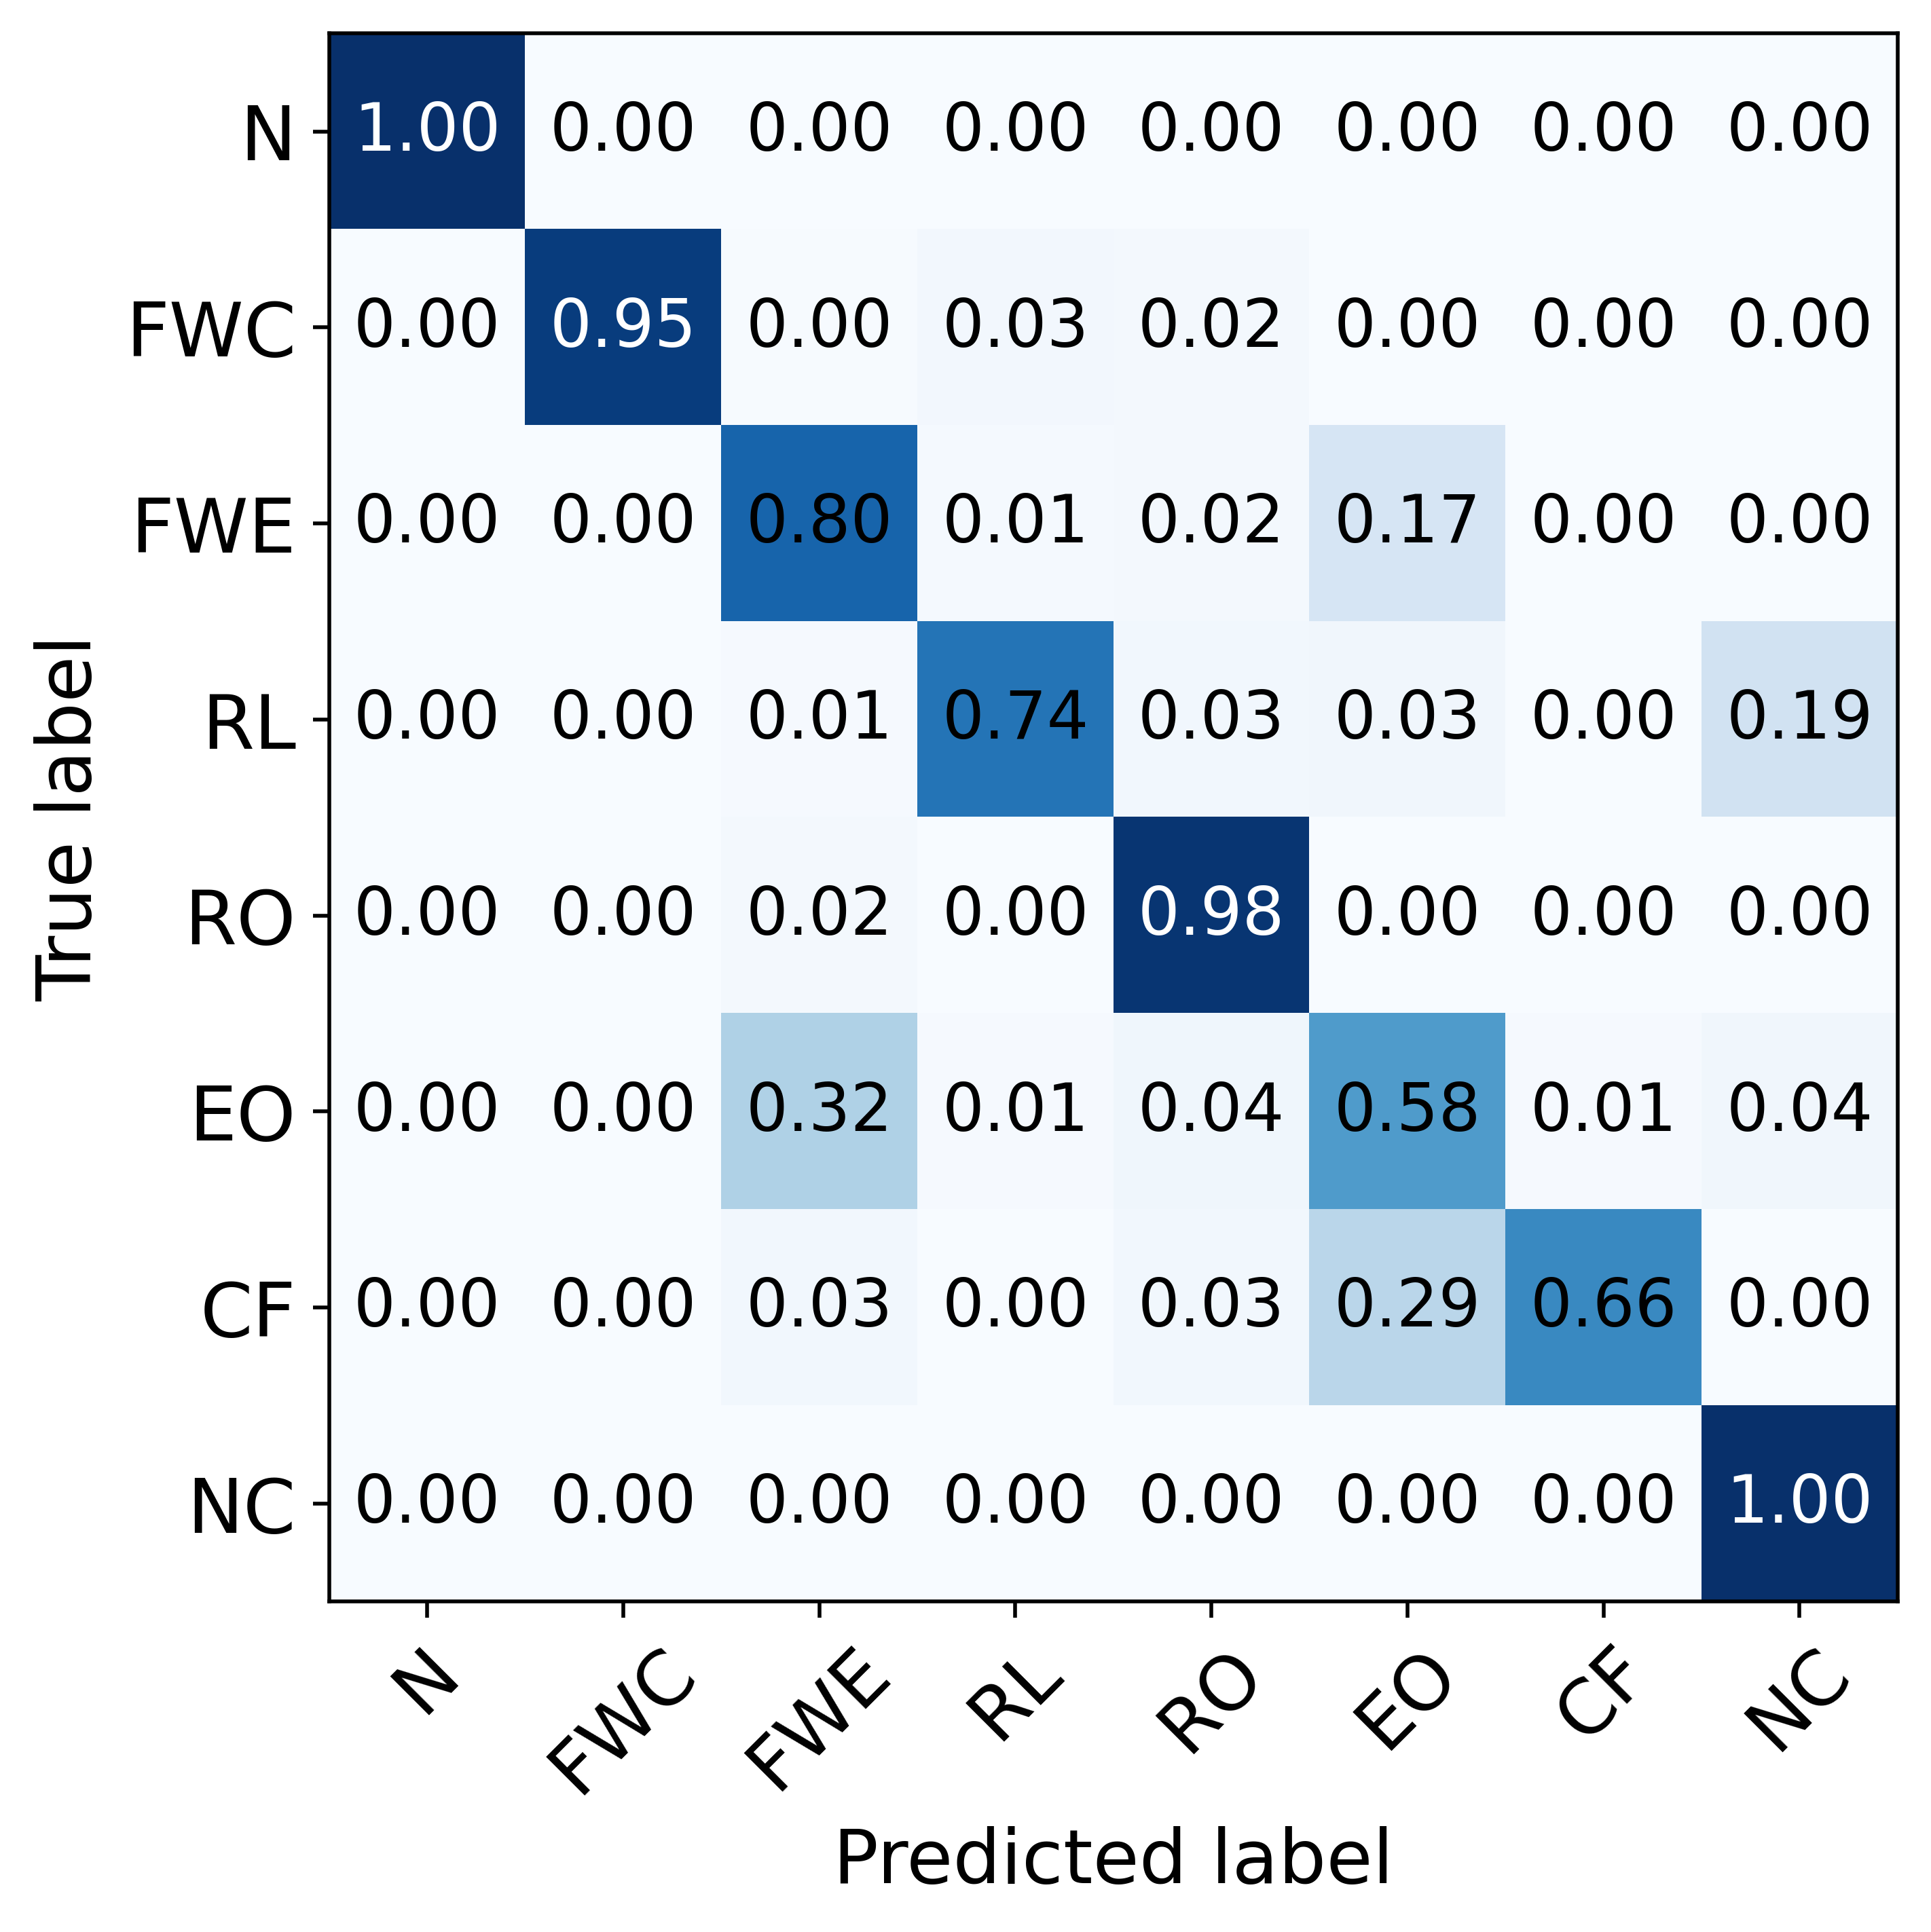

In [7]:
plot_matrix(cm, labels_name=['N', 'FWC', 'FWE', 'RL', 'RO', 'EO', 'CF', 'NC'])